# Bài tập: Dự báo chuỗi thời gian bằng RNN

## Dữ liệu đa biến - PyTorch

## Phần 0. Import thư viện & Tạo dữ liệu

   feature_1  feature_2  feature_3    target
0   0.000000   1.000000   0.049671  0.268485
1   0.100166   0.998742  -0.008810  0.319935
2   0.199325   0.994971   0.074802  0.450479
3   0.296479   0.988696   0.167353  0.508837
4   0.390650   0.979933  -0.003348  0.487590

Shape: (300, 4)


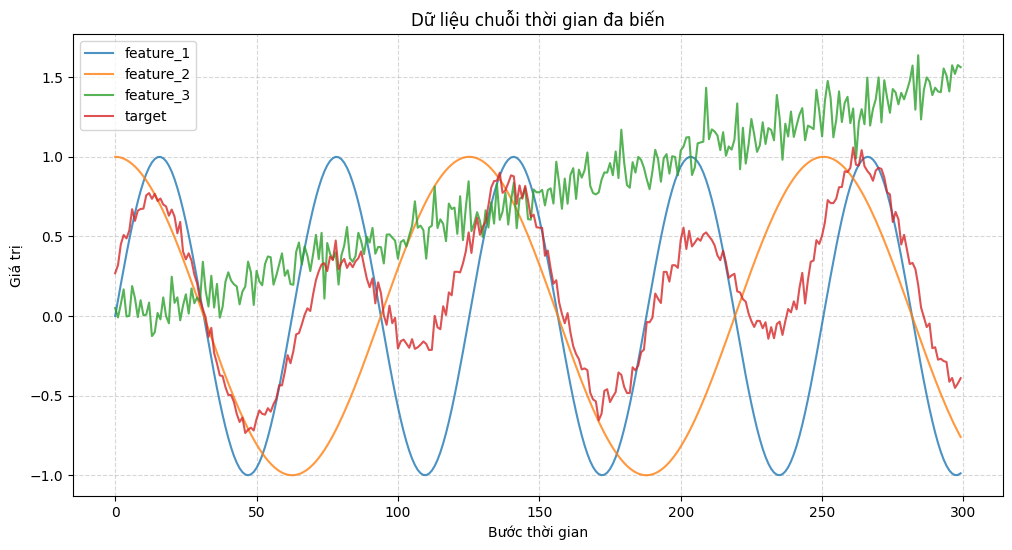

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

# Tạo dữ liệu đa biến
time_steps = 300
t = np.linspace(0, 30, time_steps)

feature_1 = np.sin(t)
feature_2 = np.cos(0.5 * t)
feature_3 = 0.05 * t + 0.1 * np.random.randn(time_steps)
target = 0.5 * feature_1 + 0.3 * feature_2 + 0.2 * feature_3 + 0.05 * np.random.randn(time_steps)

df = pd.DataFrame({
    'feature_1': feature_1,
    'feature_2': feature_2,
    'feature_3': feature_3,
    'target': target
})

print(df.head())
print(f"\nShape: {df.shape}")

plt.figure(figsize=(12,6))
for col in df.columns:
    plt.plot(df[col], label=col, alpha=0.8)
plt.legend()
plt.title("Dữ liệu chuỗi thời gian đa biến")
plt.xlabel("Bước thời gian")
plt.ylabel("Giá trị")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

---
## Phần 1. Tiền xử lý dữ liệu

- Chuẩn hóa MinMax [0,1]
- Tạo chuỗi con `seq_length = 20`
- Chia 70% train / 15% val / 15% test

In [2]:
# === 1.1 Chuẩn hóa dữ liệu ===
feature_cols = ['feature_1', 'feature_2', 'feature_3']
target_col = 'target'

scaler_features = MinMaxScaler()
scaler_target = MinMaxScaler()

features_scaled = scaler_features.fit_transform(df[feature_cols].values)
target_scaled = scaler_target.fit_transform(df[[target_col]].values)

print("Features scaled shape:", features_scaled.shape)
print("Target scaled shape:", target_scaled.shape)
print("Min/Max features:", features_scaled.min(), features_scaled.max())
print("Min/Max target:", target_scaled.min(), target_scaled.max())

Features scaled shape: (300, 3)
Target scaled shape: (300, 1)
Min/Max features: 0.0 1.0
Min/Max target: 0.0 0.9999999999999999


In [3]:
# === 1.2 Tạo chuỗi con ===
def create_sequences(features, target, seq_length):
    X, y = [], []
    for i in range(len(features) - seq_length):
        X.append(features[i:i + seq_length])
        y.append(target[i + seq_length])
    return torch.FloatTensor(np.array(X)), torch.FloatTensor(np.array(y))

seq_length = 20
X, y = create_sequences(features_scaled, target_scaled, seq_length)
print(f"X shape: {X.shape}")  # [N, seq_length, 3]
print(f"y shape: {y.shape}")  # [N, 1]

X shape: torch.Size([280, 20, 3])
y shape: torch.Size([280, 1])


In [4]:
# === 1.3 Chia dữ liệu 70/15/15 ===
n = len(X)
n_train = int(0.7 * n)
n_val = int(0.15 * n)

X_train, y_train = X[:n_train], y[:n_train]
X_val, y_val = X[n_train:n_train+n_val], y[n_train:n_train+n_val]
X_test, y_test = X[n_train+n_val:], y[n_train+n_val:]

print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

Train: 196, Val: 42, Test: 42


---
## Phần 2. Xây dựng mô hình RNN & Huấn luyện

In [5]:
# === 2.1 Định nghĩa mô hình RNN ===
class RNNModel(nn.Module):
    def __init__(self, input_size=3, hidden_size=32, output_size=1, num_layers=1, dropout=0.0):
        super(RNNModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers=num_layers,
                          batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        out, _ = self.rnn(x, h0)
        out = self.dropout(out[:, -1, :])
        out = self.fc(out)
        return out

In [6]:
# === 2.2 Hàm huấn luyện ===
def train_model(X_train, y_train, X_val, y_val, input_size=3, hidden_size=32,
                num_epochs=150, lr=0.01, num_layers=1, dropout=0.0, batch_size=32):
    model = RNNModel(input_size, hidden_size, 1, num_layers, dropout)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses = [], []

    for epoch in range(num_epochs):
        model.train()
        # Mini-batch training
        perm = torch.randperm(len(X_train))
        epoch_loss = 0
        n_batches = 0
        for i in range(0, len(X_train), batch_size):
            idx = perm[i:i+batch_size]
            xb, yb = X_train[idx], y_train[idx]
            pred = model(xb)
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        train_losses.append(epoch_loss / n_batches)

        # Validation
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val)
            val_loss = criterion(val_pred, y_val).item()
        val_losses.append(val_loss)

        if (epoch + 1) % 30 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_losses[-1]:.6f}, Val Loss: {val_loss:.6f}")

    return model, train_losses, val_losses

In [7]:
# === 2.3 Huấn luyện mô hình cơ bản ===
model_base, train_losses, val_losses = train_model(
    X_train, y_train, X_val, y_val,
    hidden_size=32, num_epochs=150, lr=0.01
)

Epoch [30/150] - Train Loss: 0.000895, Val Loss: 0.001059
Epoch [60/150] - Train Loss: 0.001400, Val Loss: 0.003198
Epoch [90/150] - Train Loss: 0.001517, Val Loss: 0.001165
Epoch [120/150] - Train Loss: 0.000989, Val Loss: 0.001117
Epoch [150/150] - Train Loss: 0.001218, Val Loss: 0.001058


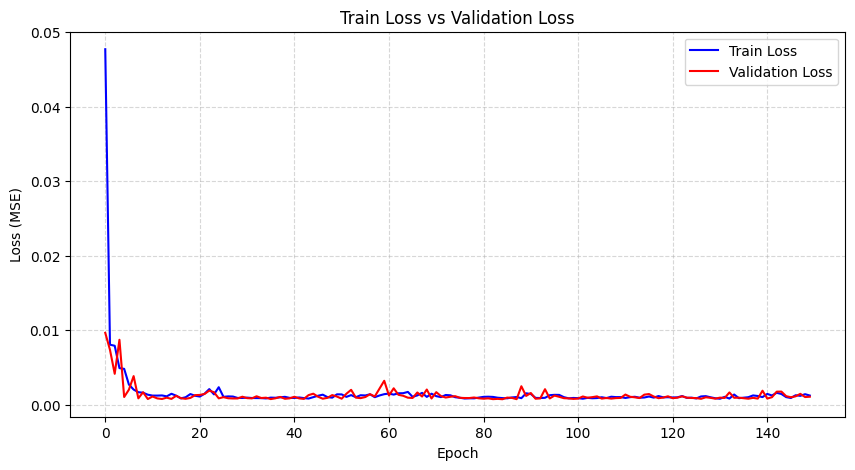

In [8]:
# === 2.4 Vẽ biểu đồ Loss ===
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(val_losses, label='Validation Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Train Loss vs Validation Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

---
## Phần 3. Đánh giá mô hình

In [9]:
# === 3.1 Dự đoán trên tập test ===
model_base.eval()
with torch.no_grad():
    y_pred_scaled = model_base(X_test).numpy()

# Inverse transform
y_pred = scaler_target.inverse_transform(y_pred_scaled)
y_actual = scaler_target.inverse_transform(y_test.numpy())

# Tính MSE, MAE
mse = mean_squared_error(y_actual, y_pred)
mae = mean_absolute_error(y_actual, y_pred)
print(f"Test MSE: {mse:.6f}")
print(f"Test MAE: {mae:.6f}")

Test MSE: 0.002743
Test MAE: 0.041816


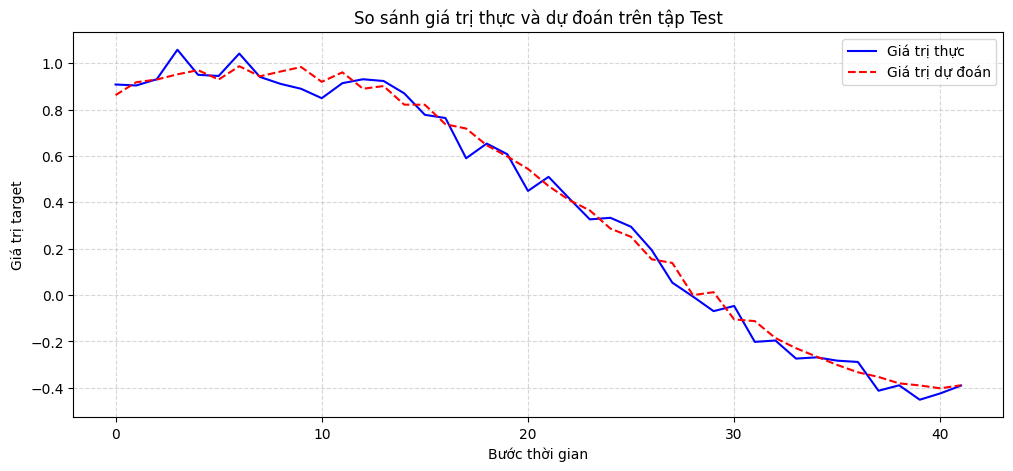

In [10]:
# === 3.2 Biểu đồ so sánh giá trị thực vs dự đoán ===
plt.figure(figsize=(12, 5))
plt.plot(y_actual, label='Giá trị thực', color='blue')
plt.plot(y_pred, label='Giá trị dự đoán', color='red', linestyle='--')
plt.title('So sánh giá trị thực và dự đoán trên tập Test')
plt.xlabel('Bước thời gian')
plt.ylabel('Giá trị target')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

---
## Phần 4. Yêu cầu nâng cao

### 4.1 So sánh seq_length = 10, 20, 30

In [11]:
results_seq = {}
for sl in [10, 20, 30]:
    print(f"\n{'='*40}")
    print(f"seq_length = {sl}")
    Xi, yi = create_sequences(features_scaled, target_scaled, sl)
    ni = len(Xi)
    nt = int(0.7*ni); nv = int(0.15*ni)
    m, tl, vl = train_model(Xi[:nt], yi[:nt], Xi[nt:nt+nv], yi[nt:nt+nv],
                             hidden_size=32, num_epochs=150, lr=0.01)
    m.eval()
    with torch.no_grad():
        yp = m(Xi[nt+nv:]).numpy()
    ya = scaler_target.inverse_transform(yi[nt+nv:].numpy())
    yp_inv = scaler_target.inverse_transform(yp)
    mse_i = mean_squared_error(ya, yp_inv)
    mae_i = mean_absolute_error(ya, yp_inv)
    results_seq[sl] = {'MSE': mse_i, 'MAE': mae_i, 'train_loss': tl, 'val_loss': vl}
    print(f"  MSE={mse_i:.6f}, MAE={mae_i:.6f}")

print("\n--- Tổng hợp ---")
for k, v in results_seq.items():
    print(f"seq_length={k}: MSE={v['MSE']:.6f}, MAE={v['MAE']:.6f}")


seq_length = 10
Epoch [30/150] - Train Loss: 0.001017, Val Loss: 0.000695
Epoch [60/150] - Train Loss: 0.000945, Val Loss: 0.000949
Epoch [90/150] - Train Loss: 0.001037, Val Loss: 0.000935
Epoch [120/150] - Train Loss: 0.000938, Val Loss: 0.000899
Epoch [150/150] - Train Loss: 0.000826, Val Loss: 0.001167
  MSE=0.002729, MAE=0.041818

seq_length = 20
Epoch [30/150] - Train Loss: 0.000962, Val Loss: 0.001764
Epoch [60/150] - Train Loss: 0.000866, Val Loss: 0.001051
Epoch [90/150] - Train Loss: 0.000860, Val Loss: 0.000905
Epoch [120/150] - Train Loss: 0.000964, Val Loss: 0.001295
Epoch [150/150] - Train Loss: 0.001184, Val Loss: 0.001466
  MSE=0.003279, MAE=0.043586

seq_length = 30
Epoch [30/150] - Train Loss: 0.001240, Val Loss: 0.000993
Epoch [60/150] - Train Loss: 0.000934, Val Loss: 0.000981
Epoch [90/150] - Train Loss: 0.001078, Val Loss: 0.000897
Epoch [120/150] - Train Loss: 0.000917, Val Loss: 0.000942
Epoch [150/150] - Train Loss: 0.001112, Val Loss: 0.001719
  MSE=0.004274,

**Nhận xét seq_length:**
- `seq_length` ngắn (10): mô hình ít ngữ cảnh, dự đoán kém hơn.
- `seq_length` trung bình (20): cân bằng tốt giữa ngữ cảnh và tránh nhiễu.
- `seq_length` dài (30): nhiều ngữ cảnh hơn nhưng có thể gây khó khăn cho RNN cơ bản do vanishing gradient.

### 4.2 So sánh hidden_size = 16, 32, 64

In [12]:
results_hs = {}
for hs in [16, 32, 64]:
    print(f"\nhidden_size = {hs}")
    m, tl, vl = train_model(X_train, y_train, X_val, y_val,
                             hidden_size=hs, num_epochs=150, lr=0.01)
    m.eval()
    with torch.no_grad():
        yp = scaler_target.inverse_transform(m(X_test).numpy())
    ya = scaler_target.inverse_transform(y_test.numpy())
    mse_i = mean_squared_error(ya, yp)
    mae_i = mean_absolute_error(ya, yp)
    results_hs[hs] = {'MSE': mse_i, 'MAE': mae_i}
    print(f"  MSE={mse_i:.6f}, MAE={mae_i:.6f}")

print("\n--- Tổng hợp ---")
for k, v in results_hs.items():
    print(f"hidden_size={k}: MSE={v['MSE']:.6f}, MAE={v['MAE']:.6f}")


hidden_size = 16
Epoch [30/150] - Train Loss: 0.000896, Val Loss: 0.000765
Epoch [60/150] - Train Loss: 0.001002, Val Loss: 0.000695
Epoch [90/150] - Train Loss: 0.001296, Val Loss: 0.000807
Epoch [120/150] - Train Loss: 0.000893, Val Loss: 0.000760
Epoch [150/150] - Train Loss: 0.000930, Val Loss: 0.001010
  MSE=0.002612, MAE=0.040999

hidden_size = 32
Epoch [30/150] - Train Loss: 0.000910, Val Loss: 0.001089
Epoch [60/150] - Train Loss: 0.000949, Val Loss: 0.000785
Epoch [90/150] - Train Loss: 0.000886, Val Loss: 0.000848
Epoch [120/150] - Train Loss: 0.000903, Val Loss: 0.001270
Epoch [150/150] - Train Loss: 0.001037, Val Loss: 0.001084
  MSE=0.002690, MAE=0.043058

hidden_size = 64
Epoch [30/150] - Train Loss: 0.001728, Val Loss: 0.001571
Epoch [60/150] - Train Loss: 0.001675, Val Loss: 0.004243
Epoch [90/150] - Train Loss: 0.001212, Val Loss: 0.001208
Epoch [120/150] - Train Loss: 0.001346, Val Loss: 0.002240
Epoch [150/150] - Train Loss: 0.001630, Val Loss: 0.001118
  MSE=0.0043

### 4.3 Tăng số epoch (150 vs 300)

=== 150 epochs ===
Epoch [30/150] - Train Loss: 0.001586, Val Loss: 0.001131
Epoch [60/150] - Train Loss: 0.001374, Val Loss: 0.001007
Epoch [90/150] - Train Loss: 0.001352, Val Loss: 0.000893
Epoch [120/150] - Train Loss: 0.000886, Val Loss: 0.000897
Epoch [150/150] - Train Loss: 0.000863, Val Loss: 0.001382

=== 300 epochs ===
Epoch [30/300] - Train Loss: 0.001053, Val Loss: 0.001023
Epoch [60/300] - Train Loss: 0.001327, Val Loss: 0.001925
Epoch [90/300] - Train Loss: 0.001060, Val Loss: 0.000951
Epoch [120/300] - Train Loss: 0.002185, Val Loss: 0.000838
Epoch [150/300] - Train Loss: 0.001209, Val Loss: 0.001592
Epoch [180/300] - Train Loss: 0.000922, Val Loss: 0.000844
Epoch [210/300] - Train Loss: 0.001016, Val Loss: 0.000923
Epoch [240/300] - Train Loss: 0.001312, Val Loss: 0.001437
Epoch [270/300] - Train Loss: 0.001047, Val Loss: 0.000940
Epoch [300/300] - Train Loss: 0.000837, Val Loss: 0.000805


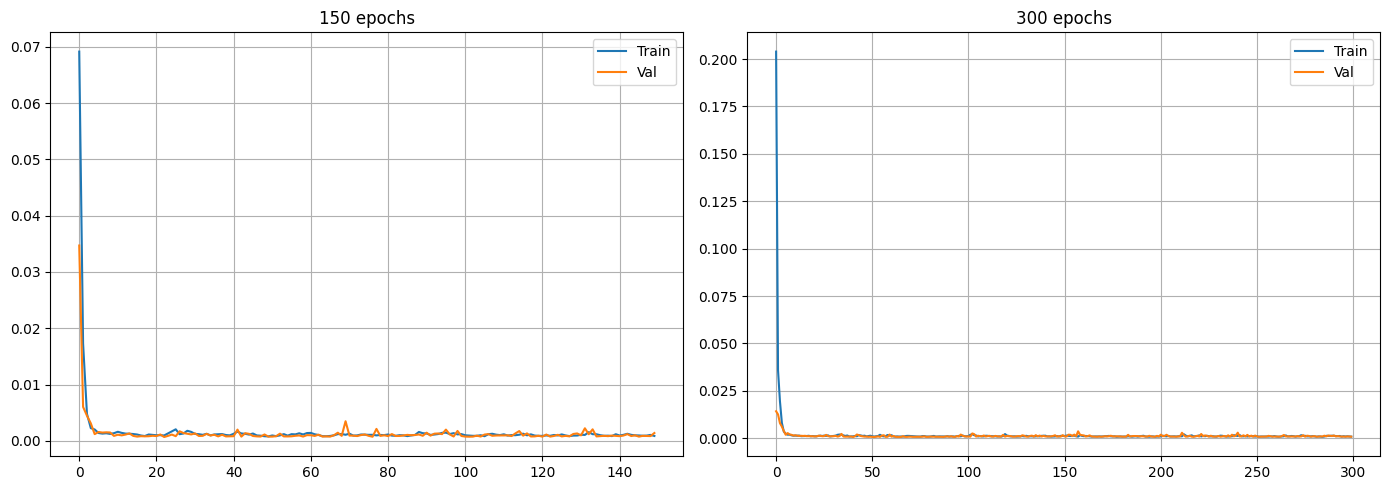

In [13]:
print("=== 150 epochs ===")
m150, tl150, vl150 = train_model(X_train, y_train, X_val, y_val, num_epochs=150)
print("\n=== 300 epochs ===")
m300, tl300, vl300 = train_model(X_train, y_train, X_val, y_val, num_epochs=300)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(tl150, label='Train'); axes[0].plot(vl150, label='Val')
axes[0].set_title('150 epochs'); axes[0].legend(); axes[0].grid(True)
axes[1].plot(tl300, label='Train'); axes[1].plot(vl300, label='Val')
axes[1].set_title('300 epochs'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.show()

### 4.4 Dự đoán nhiều bước (multi-step: 3 và 5 bước)

In [14]:
# Mô hình dự đoán multi-step
class RNNMultiStep(nn.Module):
    def __init__(self, input_size=3, hidden_size=32, output_size=1, n_steps=3):
        super().__init__()
        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size * n_steps)
        self.n_steps = n_steps

    def forward(self, x):
        h0 = torch.zeros(1, x.size(0), self.hidden_size)
        out, _ = self.rnn(x, h0)
        out = self.fc(out[:, -1, :])
        return out.view(-1, self.n_steps)

def create_sequences_multi(features, target, seq_length, n_steps):
    X, y = [], []
    for i in range(len(features) - seq_length - n_steps + 1):
        X.append(features[i:i + seq_length])
        y.append(target[i + seq_length:i + seq_length + n_steps].flatten())
    return torch.FloatTensor(np.array(X)), torch.FloatTensor(np.array(y))

for n_steps in [3, 5]:
    print(f"\n{'='*40}")
    print(f"Multi-step: {n_steps} bước")
    Xm, ym = create_sequences_multi(features_scaled, target_scaled, 20, n_steps)
    nm = len(Xm); nt = int(0.7*nm); nv = int(0.15*nm)
    
    model_ms = RNNMultiStep(3, 32, 1, n_steps)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model_ms.parameters(), lr=0.01)
    
    for epoch in range(150):
        model_ms.train()
        pred = model_ms(Xm[:nt])
        loss = criterion(pred, ym[:nt])
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        if (epoch+1) % 50 == 0:
            print(f"  Epoch {epoch+1}, Loss: {loss.item():.6f}")
    
    model_ms.eval()
    with torch.no_grad():
        yp = model_ms(Xm[nt+nv:]).numpy()
    ya = ym[nt+nv:].numpy()
    
    for step in range(n_steps):
        mse_s = mean_squared_error(ya[:, step], yp[:, step])
        print(f"  Step {step+1}: MSE={mse_s:.6f}")


Multi-step: 3 bước
  Epoch 50, Loss: 0.002710
  Epoch 100, Loss: 0.001158
  Epoch 150, Loss: 0.000899
  Step 1: MSE=0.001750
  Step 2: MSE=0.000983
  Step 3: MSE=0.000968

Multi-step: 5 bước
  Epoch 50, Loss: 0.002450
  Epoch 100, Loss: 0.001171
  Epoch 150, Loss: 0.000979
  Step 1: MSE=0.001157
  Step 2: MSE=0.001326
  Step 3: MSE=0.001112
  Step 4: MSE=0.001232
  Step 5: MSE=0.001329


### 4.5 Dropout & Tăng số tầng RNN

In [15]:
configs = [
    {"name": "1 layer, no dropout", "num_layers": 1, "dropout": 0.0},
    {"name": "2 layers, no dropout", "num_layers": 2, "dropout": 0.0},
    {"name": "2 layers, dropout=0.2", "num_layers": 2, "dropout": 0.2},
    {"name": "3 layers, dropout=0.3", "num_layers": 3, "dropout": 0.3},
]

results_arch = {}
for cfg in configs:
    print(f"\n{cfg['name']}")
    m, tl, vl = train_model(X_train, y_train, X_val, y_val,
                             num_layers=cfg['num_layers'], dropout=cfg['dropout'],
                             num_epochs=150, lr=0.01)
    m.eval()
    with torch.no_grad():
        yp = scaler_target.inverse_transform(m(X_test).numpy())
    ya = scaler_target.inverse_transform(y_test.numpy())
    mse_i = mean_squared_error(ya, yp)
    mae_i = mean_absolute_error(ya, yp)
    results_arch[cfg['name']] = {'MSE': mse_i, 'MAE': mae_i}
    print(f"  MSE={mse_i:.6f}, MAE={mae_i:.6f}")

print("\n--- Tổng hợp ---")
for k, v in results_arch.items():
    print(f"{k}: MSE={v['MSE']:.6f}, MAE={v['MAE']:.6f}")


1 layer, no dropout
Epoch [30/150] - Train Loss: 0.001238, Val Loss: 0.000787
Epoch [60/150] - Train Loss: 0.001191, Val Loss: 0.000815
Epoch [90/150] - Train Loss: 0.001346, Val Loss: 0.001779
Epoch [120/150] - Train Loss: 0.001037, Val Loss: 0.001109
Epoch [150/150] - Train Loss: 0.001320, Val Loss: 0.003389
  MSE=0.007256, MAE=0.070120

2 layers, no dropout
Epoch [30/150] - Train Loss: 0.001545, Val Loss: 0.006308
Epoch [60/150] - Train Loss: 0.000910, Val Loss: 0.001324
Epoch [90/150] - Train Loss: 0.000921, Val Loss: 0.000962
Epoch [120/150] - Train Loss: 0.001255, Val Loss: 0.001946
Epoch [150/150] - Train Loss: 0.000879, Val Loss: 0.000955
  MSE=0.002882, MAE=0.044364

2 layers, dropout=0.2
Epoch [30/150] - Train Loss: 0.003790, Val Loss: 0.001947
Epoch [60/150] - Train Loss: 0.002241, Val Loss: 0.000881
Epoch [90/150] - Train Loss: 0.002241, Val Loss: 0.001800
Epoch [120/150] - Train Loss: 0.004227, Val Loss: 0.003205
Epoch [150/150] - Train Loss: 0.003382, Val Loss: 0.001444


### 4.6 So sánh Learning Rate


lr = 0.001
Epoch [30/150] - Train Loss: 0.001698, Val Loss: 0.001412
Epoch [60/150] - Train Loss: 0.000967, Val Loss: 0.000806
Epoch [90/150] - Train Loss: 0.000880, Val Loss: 0.000749
Epoch [120/150] - Train Loss: 0.001022, Val Loss: 0.000791
Epoch [150/150] - Train Loss: 0.000900, Val Loss: 0.001043
  MSE=0.006474

lr = 0.005
Epoch [30/150] - Train Loss: 0.001167, Val Loss: 0.000826
Epoch [60/150] - Train Loss: 0.000951, Val Loss: 0.001615
Epoch [90/150] - Train Loss: 0.000845, Val Loss: 0.001207
Epoch [120/150] - Train Loss: 0.000857, Val Loss: 0.000900
Epoch [150/150] - Train Loss: 0.000924, Val Loss: 0.000865
  MSE=0.003752

lr = 0.01
Epoch [30/150] - Train Loss: 0.001317, Val Loss: 0.001134
Epoch [60/150] - Train Loss: 0.001258, Val Loss: 0.001570
Epoch [90/150] - Train Loss: 0.001634, Val Loss: 0.003516
Epoch [120/150] - Train Loss: 0.001101, Val Loss: 0.000875
Epoch [150/150] - Train Loss: 0.000961, Val Loss: 0.000814
  MSE=0.004595

lr = 0.05
Epoch [30/150] - Train Loss: 0.00

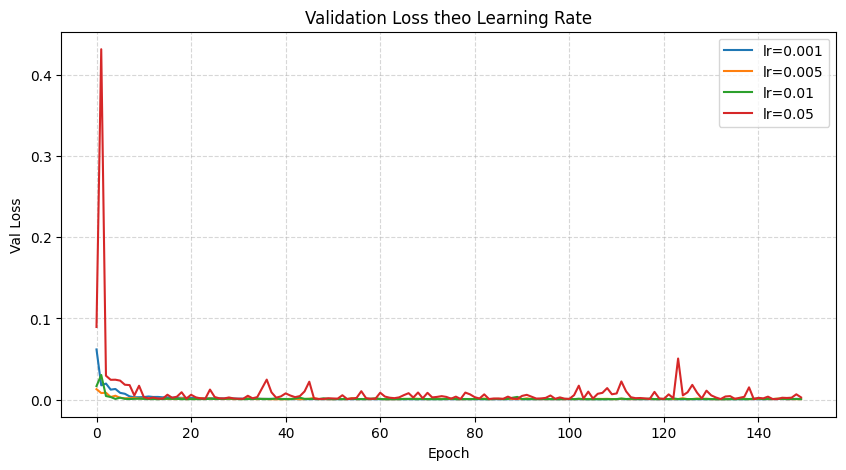

In [16]:
results_lr = {}
for lr in [0.001, 0.005, 0.01, 0.05]:
    print(f"\nlr = {lr}")
    m, tl, vl = train_model(X_train, y_train, X_val, y_val, num_epochs=150, lr=lr)
    m.eval()
    with torch.no_grad():
        yp = scaler_target.inverse_transform(m(X_test).numpy())
    ya = scaler_target.inverse_transform(y_test.numpy())
    mse_i = mean_squared_error(ya, yp)
    results_lr[lr] = {'MSE': mse_i, 'val_loss': vl}
    print(f"  MSE={mse_i:.6f}")

plt.figure(figsize=(10, 5))
for lr, v in results_lr.items():
    plt.plot(v['val_loss'], label=f'lr={lr}')
plt.xlabel('Epoch'); plt.ylabel('Val Loss')
plt.title('Validation Loss theo Learning Rate')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### 4.7 Biểu đồ sai số dự đoán theo thời điểm trên tập test

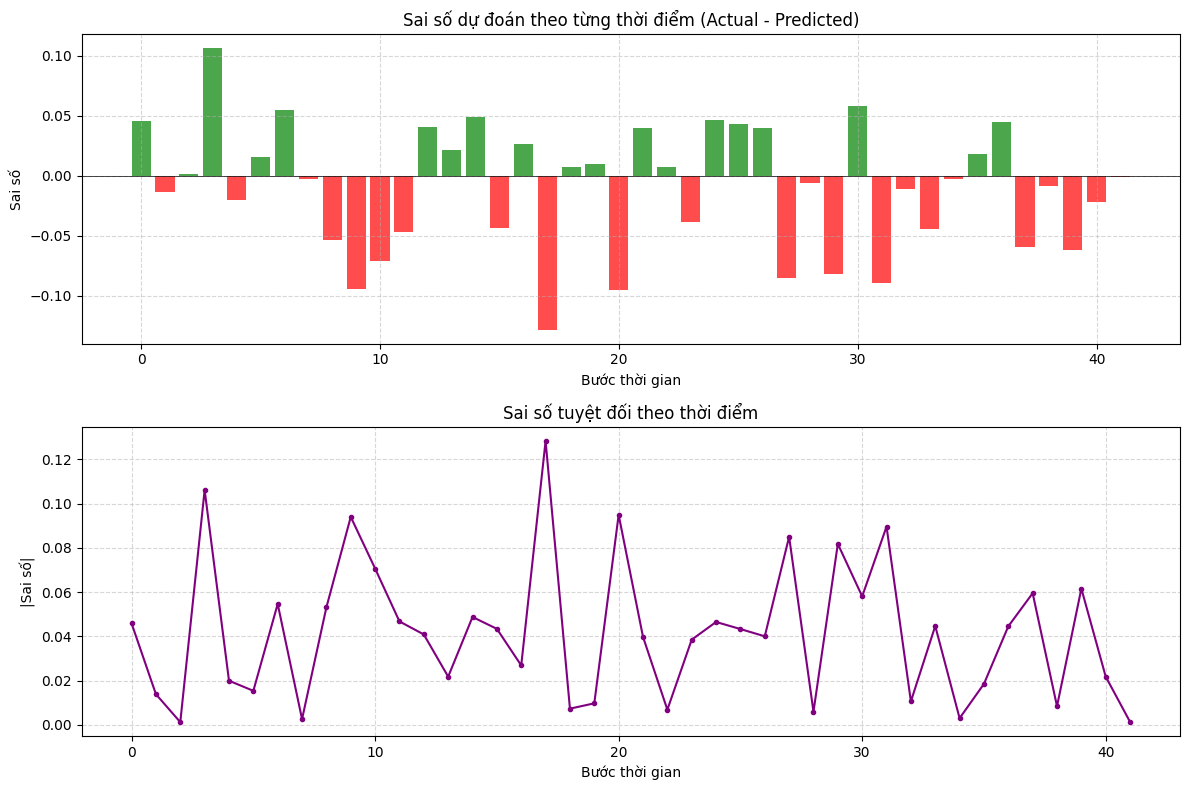

Sai số trung bình: -0.009595
Sai số tuyệt đối trung bình: 0.041816
Sai số lớn nhất: 0.128251


In [17]:
model_base.eval()
with torch.no_grad():
    y_pred_scaled = model_base(X_test).numpy()
y_pred_final = scaler_target.inverse_transform(y_pred_scaled)
y_actual_final = scaler_target.inverse_transform(y_test.numpy())
errors = y_actual_final.flatten() - y_pred_final.flatten()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].bar(range(len(errors)), errors, color=['green' if e >= 0 else 'red' for e in errors], alpha=0.7)
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[0].set_title('Sai số dự đoán theo từng thời điểm (Actual - Predicted)')
axes[0].set_xlabel('Bước thời gian'); axes[0].set_ylabel('Sai số')
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(np.abs(errors), color='purple', marker='o', markersize=3)
axes[1].set_title('Sai số tuyệt đối theo thời điểm')
axes[1].set_xlabel('Bước thời gian'); axes[1].set_ylabel('|Sai số|')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"Sai số trung bình: {np.mean(errors):.6f}")
print(f"Sai số tuyệt đối trung bình: {np.mean(np.abs(errors)):.6f}")
print(f"Sai số lớn nhất: {np.max(np.abs(errors)):.6f}")

### 4.8 Nhận xét tổng hợp

**Các yếu tố giúp mô hình dự đoán tốt hơn:**
- `seq_length` phù hợp (20): cung cấp đủ ngữ cảnh mà không quá dài gây vanishing gradient.
- `hidden_size` đủ lớn (32-64): tăng khả năng biểu diễn, nhưng quá lớn có thể overfit.
- Learning rate vừa phải (0.01): hội tụ nhanh mà ổn định.
- Dropout nhẹ (0.2): giúp giảm overfitting khi mô hình nhiều tầng.

**Các yếu tố khiến mô hình kém hơn:**
- `seq_length` quá ngắn: thiếu ngữ cảnh, dự đoán không chính xác.
- `hidden_size` quá nhỏ (16): không đủ capacity để học pattern phức tạp.
- Learning rate quá cao (0.05): gây dao động, không hội tụ ổn định.
- Dự đoán multi-step: sai số tích lũy qua các bước, các bước xa hơn có MSE cao hơn.
- RNN cơ bản gặp khó khăn với chuỗi dài do vanishing gradient → nên dùng LSTM/GRU cho bài toán phức tạp hơn.

In [18]:
import torch
torch.save(model_base.state_dict(), 'rnn_bt_model.pth')
print('Saved model_base to rnn_bt_model.pth')

Saved model_base to rnn_bt_model.pth
